
🟢 1. Instalar e baixar dataset


In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("ibadeus/pcos-xai-ultrasound-dataset")

print("Dataset path:", path)

Using Colab cache for faster access to the 'pcos-xai-ultrasound-dataset' dataset.
Dataset path: /kaggle/input/pcos-xai-ultrasound-dataset


📁 2. Ajustar caminho das imagens

In [ ]:
import os

DATA_DIR = os.path.join(path, "PCOS")
print(os.listdir(DATA_DIR))

['infected', 'noninfected']


🔥 3. Imports

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando:", DEVICE)

Usando: cuda


🖼️ 4. Transformações

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

## 🧹 4.5 Remoção de Imagens Duplicadas

> **Por que essa etapa?** Datasets de imagens médicas disponíveis publicamente frequentemente contêm imagens duplicadas — arquivos idênticos que aparecem em diferentes pastas ou que foram incluídos múltiplas vezes durante a curadoria. No contexto deste dataset PCOS do Kaggle, esse problema é documentado na literatura: imagens do mesmo paciente capturadas em momentos diferentes podem aparecer tanto no treino quanto na validação após o split, causando **data leakage** e inflando artificialmente as métricas. A detecção é feita via hash MD5 — dois arquivos com hash idêntico são byte-a-byte iguais, independentemente do nome do arquivo.

In [ ]:
import hashlib
import os
import shutil
from pathlib import Path
from collections import defaultdict

# ── O diretório /kaggle/input é somente leitura no Colab.
# ── A estratégia correta é COPIAR apenas as imagens únicas
# ── para um novo diretório em /tmp, e usar esse como DATA_DIR.
CLEAN_DIR = '/tmp/pcos_clean'

def file_hash(path):
    """Calcula o hash MD5 do conteúdo binário do arquivo."""
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

# ── Mapeia hash → primeiro caminho encontrado (único a ser mantido) ──
hash_map = {}       # hash -> Path do arquivo original (primeiro encontrado)
duplicatas = []     # lista de caminhos duplicados (ignorados)
extensoes = {'.jpg', '.jpeg', '.png', '.bmp'}

total_vistos = 0
for img_path in sorted(Path(DATA_DIR).rglob('*')):
    if img_path.suffix.lower() in extensoes:
        total_vistos += 1
        h = file_hash(img_path)
        if h not in hash_map:
            hash_map[h] = img_path   # primeira ocorrência: mantém
        else:
            duplicatas.append(img_path)  # duplicata: ignora

print(f'Total de imagens encontradas : {total_vistos}')
print(f'Imagens únicas               : {len(hash_map)}')
print(f'Duplicatas ignoradas         : {len(duplicatas)}')

if duplicatas:
    print('\nExemplos de duplicatas detectadas (primeiras 5):')
    for p in duplicatas[:5]:
        print(f'  → {p}')

# ── Copia as imagens únicas mantendo a estrutura de pastas ──
# ── (ex: infected/ e noninfected/) para CLEAN_DIR            ──
if os.path.exists(CLEAN_DIR):
    shutil.rmtree(CLEAN_DIR)   # limpa execuções anteriores

copiados = 0
for h, src_path in hash_map.items():
    # Reconstrói o caminho relativo a partir de DATA_DIR
    rel = src_path.relative_to(DATA_DIR)
    dst_path = Path(CLEAN_DIR) / rel
    dst_path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src_path, dst_path)
    copiados += 1

print(f'\n✅ Cópia concluída: {copiados} imagens únicas em {CLEAN_DIR}')

# ── Atualiza DATA_DIR para o restante do notebook ──
DATA_DIR = CLEAN_DIR
print(f'   DATA_DIR atualizado para: {DATA_DIR}')
print(f'   Subpastas: {os.listdir(DATA_DIR)}')


Total de imagens encontradas : 11784
Imagens únicas               : 3996
Duplicatas ignoradas         : 7788

Exemplos de duplicatas detectadas (primeiras 5):
  → /kaggle/input/pcos-xai-ultrasound-dataset/PCOS/infected/Image_002.jpg
  → /kaggle/input/pcos-xai-ultrasound-dataset/PCOS/infected/Image_004.jpg
  → /kaggle/input/pcos-xai-ultrasound-dataset/PCOS/infected/Image_006.jpg
  → /kaggle/input/pcos-xai-ultrasound-dataset/PCOS/infected/Image_008.jpg
  → /kaggle/input/pcos-xai-ultrasound-dataset/PCOS/infected/Image_010.jpg

✅ Cópia concluída: 3996 imagens únicas em /tmp/pcos_clean
   DATA_DIR atualizado para: /tmp/pcos_clean
   Subpastas: ['infected', 'noninfected']


📊 5. Dataset + Split

In [ ]:
from torchvision import datasets
from torch.utils.data import DataLoader, Subset, random_split
import torch

# Dataset com transformações de treino
train_full_dataset = datasets.ImageFolder(
    DATA_DIR,
    transform=train_transforms
)

# Dataset separado com transformações de validação
val_full_dataset = datasets.ImageFolder(
    DATA_DIR,
    transform=val_transforms
)

# Tamanhos
train_size = int(0.8 * len(train_full_dataset))
val_size = len(train_full_dataset) - train_size

# Gera os mesmos índices para treino e validação (seed fixo = reprodutível)
generator = torch.Generator().manual_seed(42)

train_subset, val_subset = random_split(
    range(len(train_full_dataset)),
    [train_size, val_size],
    generator=generator
)

train_indices = list(train_subset.indices)
val_indices   = list(val_subset.indices)

# Subsets com transform correto para cada split
train_dataset = Subset(train_full_dataset, train_indices)
val_dataset   = Subset(val_full_dataset,   val_indices)

# DataLoader de validação — sem sampler, sem shuffle
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print('Treino   :', len(train_dataset))
print('Validação:', len(val_dataset))
print('Classes  :', train_full_dataset.classes)
print('Mapeamento:', train_full_dataset.class_to_idx)


Treino   : 3196
Validação: 800
Classes  : ['infected', 'noninfected']
Mapeamento: {'infected': 0, 'noninfected': 1}


## ⚖️ 5.2 Balanceamento com WeightedRandomSampler

> **Por que essa etapa?** Após a remoção de duplicatas o dataset ficou com razão de ~4:1 entre classes (infected: 79,7% vs noninfected: 20,3%). Nesse nível de desbalanceamento o modelo tende a aprender a prever sempre a classe majoritária, atingindo alta acurácia global mas com recall muito baixo para `noninfected` — que é exatamente a classe que representa pacientes saudáveis sendo erroneamente classificadas como doentes (falsos positivos) ou vice-versa.

> O `WeightedRandomSampler` resolve isso atribuindo um **peso inversamente proporcional à frequência** de cada classe na amostragem do DataLoader. A classe minoritária (`noninfected`) é amostrada com maior frequência, fazendo com que cada batch visto pelo modelo tenha proporção aproximadamente igual entre as classes — **sem descartar nenhuma imagem e sem alterar os arquivos no disco**.

In [ ]:
from torch.utils.data import WeightedRandomSampler
import numpy as np

# ── Obtém o label de cada amostra do split de treino ──
# train_full_dataset.targets contém todos os labels na ordem do ImageFolder
# train_indices são os índices selecionados para o treino
train_labels = [train_full_dataset.targets[i] for i in train_indices]

# ── Calcula a contagem por classe no treino ──
classes      = train_full_dataset.classes          # ['infected', 'noninfected']
class_counts = np.bincount(train_labels)           # ex: [2547, 649]

print('Distribuição no split de treino (antes do sampler):')
for name, count in zip(classes, class_counts):
    print(f'  {name:<14}: {count} ({100*count/len(train_labels):.1f}%)')

# ── Peso por classe: inversamente proporcional à frequência ──
# Classe com menos amostras recebe peso maior
class_weights = 1.0 / class_counts.astype(float)

# ── Peso por amostra: cada imagem recebe o peso da sua classe ──
sample_weights = np.array([class_weights[label] for label in train_labels])

# ── Cria o sampler ──
# num_samples = len(train_dataset) garante que uma época tem o mesmo
# número de passos que antes — apenas a distribuição muda
sampler = WeightedRandomSampler(
    weights     = torch.tensor(sample_weights, dtype=torch.float),
    num_samples = len(train_dataset),
    replacement = True   # necessário para oversampling da classe minoritária
)

# ── DataLoader de treino com sampler ──
# IMPORTANTE: shuffle=False quando usar sampler (o sampler já controla a ordem)
train_loader = DataLoader(
    train_dataset,
    batch_size = 16,
    sampler    = sampler,   # substitui shuffle=True
    num_workers= 0
)

# ── Verificação: conta distribuição em 1 época simulada ──
print('\nVerificação da distribuição após WeightedRandomSampler (1 época):')
counts_check = np.zeros(len(classes), dtype=int)
for _, labels in train_loader:
    for l in labels.numpy():
        counts_check[l] += 1

for name, count in zip(classes, counts_check):
    print(f'  {name:<14}: {count} ({100*count/counts_check.sum():.1f}%)')

print(f'\n✅ train_loader pronto com WeightedRandomSampler')
print(f'   Batches por época: {len(train_loader)}')


Distribuição no split de treino (antes do sampler):
  infected      : 2553 (79.9%)
  noninfected   : 643 (20.1%)

Verificação da distribuição após WeightedRandomSampler (1 época):
  infected      : 1572 (49.2%)
  noninfected   : 1624 (50.8%)

✅ train_loader pronto com WeightedRandomSampler
   Batches por época: 200


📊 5.1 Distribuição das Classes

> **Por que esse gráfico?** Antes de treinar qualquer modelo, é fundamental verificar se o dataset está balanceado. Um desbalanceamento entre as classes (ex: muito mais imagens `noninfected` do que `infected`) pode fazer o modelo aprender a "chutar" sempre a classe majoritária, inflando a acurácia global sem realmente aprender a diferenciar os casos. Esse gráfico torna esse problema visível logo no início da análise.

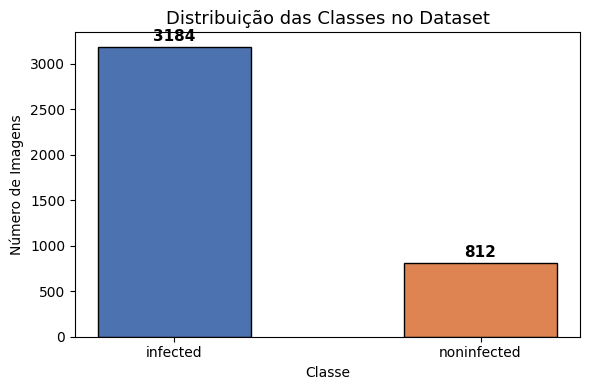

infected: 3184 imagens (79.7%)
noninfected: 812 imagens (20.3%)


In [ ]:
# Conta quantas amostras existem por classe no dataset completo
class_names = train_full_dataset.classes
class_counts = [train_full_dataset.targets.count(i) for i in range(len(class_names))]

colors = ['#4C72B0', '#DD8452']

plt.figure(figsize=(6, 4))
bars = plt.bar(class_names, class_counts, color=colors, edgecolor='black', width=0.5)

# Anota a quantidade em cima de cada barra
for bar, count in zip(bars, class_counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
             str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Distribuição das Classes no Dataset', fontsize=13)
plt.ylabel('Número de Imagens')
plt.xlabel('Classe')
plt.tight_layout()
plt.show()

total = sum(class_counts)
for name, count in zip(class_names, class_counts):
    print(f"{name}: {count} imagens ({100*count/total:.1f}%)")

🤖 6. Modelo (ResNet18)

In [ ]:
model = models.resnet18(pretrained=True)

# Congelar camadas
for param in model.parameters():
    param.requires_grad = False

# Nova camada final
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(DEVICE)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]


⚙️ 7. Treinamento

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

criterion = nn.CrossEntropyLoss()

# Treina apenas a camada final da ResNet
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

EPOCHS = 8

train_losses = []
val_losses = []
train_accs = []
val_accs = []

# Listas finais da validação, usadas depois em:
# classification_report, matriz de confusão e curva ROC
all_preds = []
all_labels = []
all_probs = []

for epoch in range(EPOCHS):
    # ─────────────────────────────
    # Treino
    # ─────────────────────────────
    model.train()

    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds_train = torch.argmax(outputs, dim=1)
        correct_train += (preds_train == labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_loss / total_train
    train_acc = correct_train / total_train

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ─────────────────────────────
    # Validação
    # ─────────────────────────────
    model.eval()

    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    epoch_preds = []
    epoch_labels = []
    epoch_probs = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            probs = F.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

            epoch_preds.extend(preds.cpu().numpy())
            epoch_labels.extend(labels.cpu().numpy())

            # Guarda TODAS as probabilidades:
            # shape final esperado: [N, num_classes]
            epoch_probs.extend(probs.cpu().numpy())

    val_loss = running_val_loss / total_val
    val_acc = correct_val / total_val

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # Mantém os resultados da última época para avaliação final
    all_preds = epoch_preds
    all_labels = epoch_labels
    all_probs = epoch_probs

    print(
        f"Epoch {epoch+1}/{EPOCHS} "
        f"- Train Loss: {train_loss:.4f} "
        f"- Train Acc: {train_acc:.4f} "
        f"- Val Loss: {val_loss:.4f} "
        f"- Val Acc: {val_acc:.4f}"
    )

Epoch 1/8 - Train Loss: 0.3575 - Train Acc: 0.8492 - Val Loss: 0.2061 - Val Acc: 0.9275
Epoch 2/8 - Train Loss: 0.2377 - Train Acc: 0.9068 - Val Loss: 0.1544 - Val Acc: 0.9437
Epoch 3/8 - Train Loss: 0.2444 - Train Acc: 0.9011 - Val Loss: 0.1439 - Val Acc: 0.9475
Epoch 4/8 - Train Loss: 0.2168 - Train Acc: 0.9121 - Val Loss: 0.1068 - Val Acc: 0.9675
Epoch 5/8 - Train Loss: 0.1917 - Train Acc: 0.9258 - Val Loss: 0.1551 - Val Acc: 0.9363
Epoch 6/8 - Train Loss: 0.2103 - Train Acc: 0.9124 - Val Loss: 0.0808 - Val Acc: 0.9738
Epoch 7/8 - Train Loss: 0.1968 - Train Acc: 0.9252 - Val Loss: 0.0879 - Val Acc: 0.9750
Epoch 8/8 - Train Loss: 0.1986 - Train Acc: 0.9161 - Val Loss: 0.1302 - Val Acc: 0.9487


📈 8. Avaliação

In [ ]:
print("\nRelatório de Classificação:")
print(classification_report(all_labels, all_preds, target_names=train_full_dataset.classes))


Relatório de Classificação:
              precision    recall  f1-score   support

    infected       0.99      0.94      0.97       631
 noninfected       0.82      0.96      0.89       169

    accuracy                           0.95       800
   macro avg       0.91      0.95      0.93       800
weighted avg       0.95      0.95      0.95       800



📊 9. Gráfico — Loss por Época

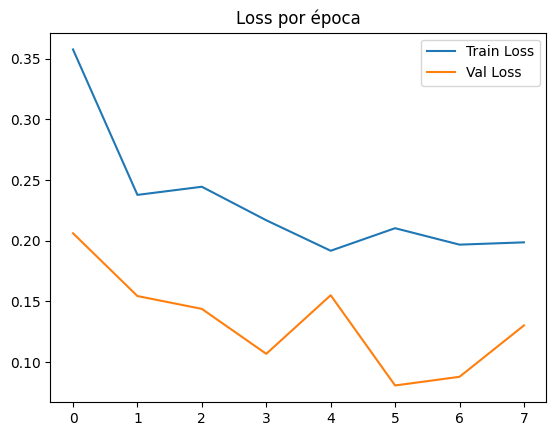

In [ ]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss por época")
plt.show()

📊 10. Acurácia por Época

> **Por que esse gráfico?** Acompanhar a acurácia separadamente da loss permite identificar dois problemas clássicos: **underfitting** (quando treino e validação têm acurácia baixa) e **overfitting** (quando a acurácia de treino sobe, mas a de validação estagna ou cai). No contexto de diagnóstico médico de SOP, um modelo com overfitting pode ter excelente desempenho nos dados de treino, mas falhar em imagens novas — o que é crítico numa aplicação clínica real.

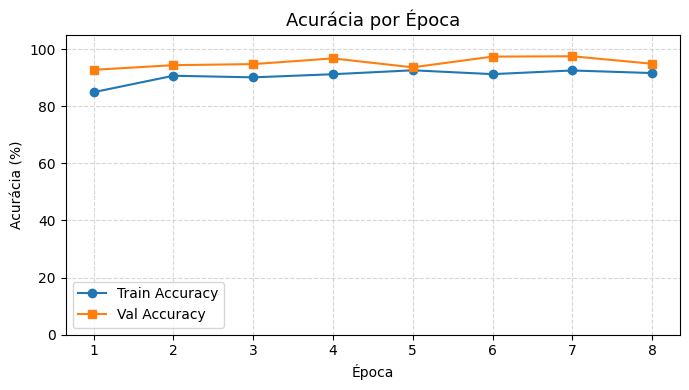

Melhor acurácia de validação: 97.50% (Época 7)


In [ ]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, [a * 100 for a in train_accs], marker='o', label='Train Accuracy')
plt.plot(epochs_range, [a * 100 for a in val_accs], marker='s', label='Val Accuracy')
plt.title('Acurácia por Época', fontsize=13)
plt.xlabel('Época')
plt.ylabel('Acurácia (%)')
plt.xticks(epochs_range)
plt.ylim(0, 105)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Melhor acurácia de validação: {max(val_accs)*100:.2f}% (Época {val_accs.index(max(val_accs))+1})")

📊 11. Matriz de Confusão

> **Por que esse gráfico?** A matriz de confusão detalha exatamente onde o modelo erra. No contexto de diagnóstico de SOP, os **falsos negativos** (paciente com SOP classificada como normal) são especialmente graves, pois implicam em diagnóstico perdido e atraso no tratamento. A matriz permite quantificar esses casos e entender se o modelo tem viés para alguma das classes.

Classes: ['infected', 'noninfected']
Mapeamento: {'infected': 0, 'noninfected': 1}


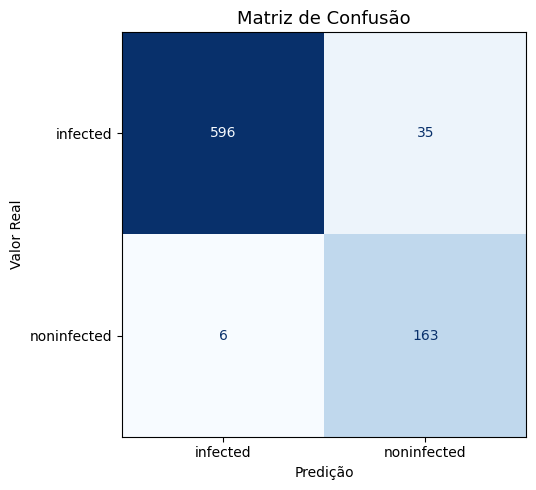


── Interpretação considerando 'infected' como classe positiva ──
Verdadeiros Positivos — infected correto: 596
Verdadeiros Negativos — noninfected correto: 163
Falsos Positivos — noninfected previsto como infected: 6
Falsos Negativos — infected previsto como noninfected: 35 ← casos críticos de diagnóstico perdido


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Usa a ordem real das classes do ImageFolder
class_names = train_full_dataset.classes
class_to_idx = train_full_dataset.class_to_idx

print("Classes:", class_names)
print("Mapeamento:", class_to_idx)

cm = confusion_matrix(
    all_labels,
    all_preds,
    labels=list(range(len(class_names)))
)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

ax.set_title("Matriz de Confusão", fontsize=13)
ax.set_xlabel("Predição")
ax.set_ylabel("Valor Real")

plt.tight_layout()
plt.show()

# ───────────────────────────────────────────────
# Interpretação específica para infected
# ───────────────────────────────────────────────
infected_idx = class_to_idx["infected"]
noninfected_idx = class_to_idx["noninfected"]

tp_infected = cm[infected_idx, infected_idx]
fn_infected = cm[infected_idx, noninfected_idx]
fp_infected = cm[noninfected_idx, infected_idx]
tn_infected = cm[noninfected_idx, noninfected_idx]

print("\n── Interpretação considerando 'infected' como classe positiva ──")
print(f"Verdadeiros Positivos — infected correto: {tp_infected}")
print(f"Verdadeiros Negativos — noninfected correto: {tn_infected}")
print(f"Falsos Positivos — noninfected previsto como infected: {fp_infected}")
print(f"Falsos Negativos — infected previsto como noninfected: {fn_infected} ← casos críticos de diagnóstico perdido")

📊 12. Curva ROC e AUC

> **Por que esse gráfico?** A curva ROC avalia a capacidade discriminativa do modelo em **todos os limiares de decisão possíveis**, não apenas no limiar padrão de 0.5. O valor de AUC (Área Sob a Curva) é uma métrica amplamente utilizada em diagnóstico clínico: um AUC de 1.0 indica classificação perfeita, enquanto 0.5 equivale a chute aleatório. Isso é especialmente útil em cenários médicos onde pode ser necessário **ajustar o limiar** para priorizar sensibilidade (recall de infected) em detrimento de especificidade.

Mapeamento de classes: {'infected': 0, 'noninfected': 1}


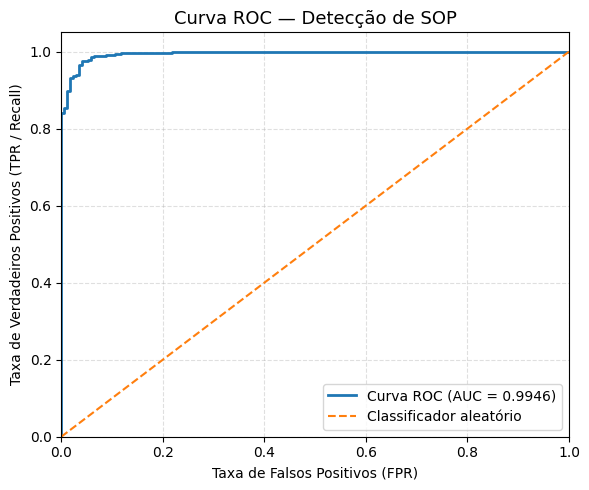

AUC: 0.9946
Excelente poder discriminativo (AUC ≥ 0.99)


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# ───────────────────────────────────────────────
# Usa o mapeamento real do ImageFolder
# ───────────────────────────────────────────────
class_to_idx = train_full_dataset.class_to_idx

print("Mapeamento de classes:", class_to_idx)

# Define qual classe é o "positivo" (infected)
positive_class = "infected"
positive_idx = class_to_idx[positive_class]

# ───────────────────────────────────────────────
# all_labels deve estar no formato binário (0/1)
# garantindo que 1 = classe positiva (infected)
# ───────────────────────────────────────────────
all_labels_binary = np.array([
    1 if label == positive_idx else 0
    for label in all_labels
])

# ───────────────────────────────────────────────
# all_probs deve conter o vetor completo de probs
# shape esperado: [N, num_classes]
# Pegamos diretamente a prob da classe positiva
# ───────────────────────────────────────────────
all_probs = np.array(all_probs)  # garantir numpy

if all_probs.ndim == 1:
    raise ValueError("all_probs deve conter probabilidades de TODAS as classes, não apenas uma.")

positive_probs = all_probs[:, positive_idx]

# ───────────────────────────────────────────────
# Curva ROC
# ───────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(all_labels_binary, positive_probs)
roc_auc = auc(fpr, tpr)

# ───────────────────────────────────────────────
# Plot
# ───────────────────────────────────────────────
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', lw=1.5, label='Classificador aleatório')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR / Recall)')
plt.title('Curva ROC — Detecção de SOP', fontsize=13)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# ───────────────────────────────────────────────
# Interpretação
# ───────────────────────────────────────────────
print(f"AUC: {roc_auc:.4f}")

if roc_auc >= 0.99:
    print("Excelente poder discriminativo (AUC ≥ 0.99)")
elif roc_auc >= 0.90:
    print("Ótimo poder discriminativo (AUC entre 0.90 e 0.99)")
elif roc_auc >= 0.75:
    print("Bom poder discriminativo (AUC entre 0.75 e 0.90)")
else:
    print("Poder discriminativo baixo — revisar modelo/dados")

## 🔍 13. Predict em Imagem Nova (nunca vista pelo modelo)

> **Por que essa etapa?** Testar o modelo com uma imagem completamente externa ao dataset de treino e validação é a verificação mais próxima de um uso real. Garante que o pipeline de inferência está correto (transformações, device, softmax) e que o modelo generaliza além dos dados que ele conhece. O rótulo real desta imagem é **infected**, permitindo verificar se a predição está correta.

Saving ovario_br_analises.jpg to ovario_br_analises.jpg
Imagem carregada: ovario_br_analises.jpg
Mapeamento de classes usado pelo modelo:
{'infected': 0, 'noninfected': 1}


/tmp/ipykernel_5440/3488888645.py:92: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


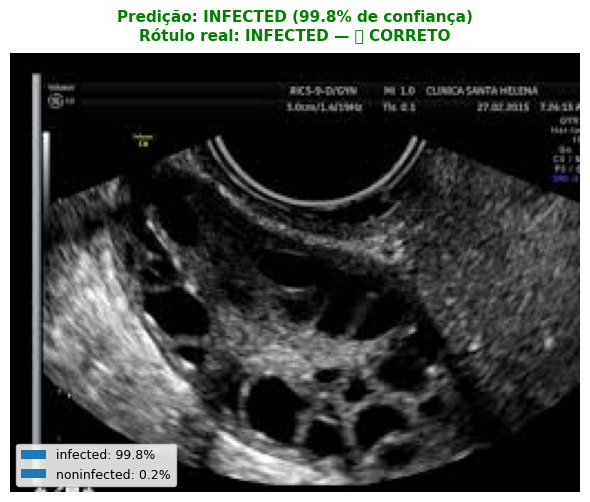


── Resultado do Predict ──
Imagem      : ovario_br_analises.jpg
Rótulo real : infected
Predição    : infected
Confiança   : 99.83%

Probabilidades por classe:
  P(    infected): 99.83%
  P( noninfected): 0.17%

Resultado   : ✅ CORRETO


In [ ]:
from PIL import Image
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ──────────────────────────────────────────────────
# Ajuste este caminho para o local da sua imagem
# ──────────────────────────────────────────────────
from google.colab import files

uploaded = files.upload()

IMG_PATH = list(uploaded.keys())[0]
print("Imagem carregada:", IMG_PATH)

# Rótulo real conhecido para validação manual
# Use exatamente o mesmo nome da pasta/classe do ImageFolder:
# infected ou noninfected
ROTULO_REAL = "infected"

# Mapeamento correto vindo do ImageFolder
class_to_idx = train_full_dataset.class_to_idx
idx_to_class = {idx: classe for classe, idx in class_to_idx.items()}

print("Mapeamento de classes usado pelo modelo:")
print(class_to_idx)

# ── Carrega e pré-processa a imagem ──
img_pil = Image.open(IMG_PATH).convert("RGB")

# Usa as mesmas transformações da validação/teste
img_tensor = val_transforms(img_pil).unsqueeze(0).to(DEVICE)

# ── Inferência ──
model.eval()

with torch.no_grad():
    output = model(img_tensor)
    probs = F.softmax(output, dim=1).squeeze(0)

pred_idx = int(torch.argmax(probs).item())
pred_label = idx_to_class[pred_idx]
confidence = float(probs[pred_idx].item() * 100)

# ── Validação manual ──
acertou = pred_label == ROTULO_REAL
cor_borda = "green" if acertou else "red"
status = "✅ CORRETO" if acertou else "❌ INCORRETO"

# ── Exibição ──
fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(img_pil)
ax.axis("off")

titulo = (
    f"Predição: {pred_label.upper()} ({confidence:.1f}% de confiança)\n"
    f"Rótulo real: {ROTULO_REAL.upper()} — {status}"
)

ax.set_title(
    titulo,
    fontsize=11,
    color=cor_borda,
    fontweight="bold",
    pad=10
)

# Borda colorida ao redor da imagem
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor(cor_borda)
    spine.set_linewidth(4)

# Legenda dinâmica, sem assumir que infected é 0 ou noninfected é 1
patches = []
for idx, classe in idx_to_class.items():
    patches.append(
        mpatches.Patch(
            label=f"{classe}: {probs[idx].item() * 100:.1f}%"
        )
    )

ax.legend(
    handles=patches,
    loc="lower left",
    fontsize=9,
    framealpha=0.85,
    facecolor="white"
)

plt.tight_layout()
plt.show()

# ── Resumo textual ──
print("\n── Resultado do Predict ──")
print(f"Imagem      : {IMG_PATH}")
print(f"Rótulo real : {ROTULO_REAL}")
print(f"Predição    : {pred_label}")
print(f"Confiança   : {confidence:.2f}%")

print("\nProbabilidades por classe:")
for idx, classe in idx_to_class.items():
    print(f"  P({classe:>12}): {probs[idx].item() * 100:.2f}%")

print(f"\nResultado   : {status}")

## 📊 14. Distribuição das Classes — Treino vs Validação

> **Por que esse gráfico?** Após o `random_split`, é importante confirmar que a proporção entre as classes se manteve similar nos dois conjuntos. Se o split aleatorio concentrar muito `infected` no treino e pouco na validação (ou vice-versa), as métricas de validação deixam de ser representativas do desempenho real do modelo.

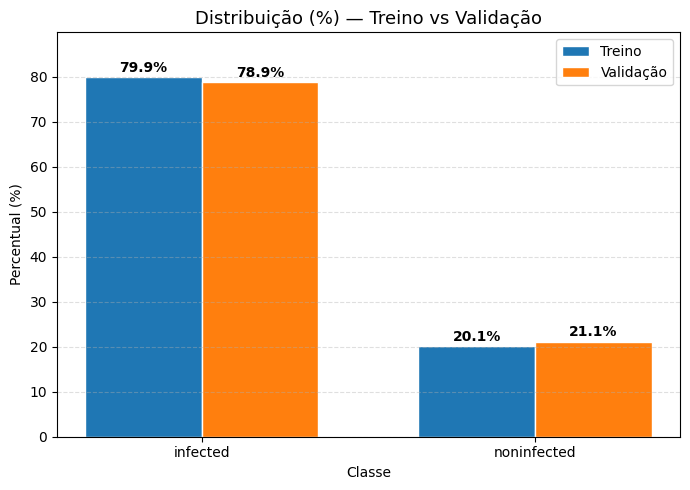

Classe         Treino (n)  Treino (%)   Val (n)   Val (%)
----------------------------------------------------------
infected             2553       79.9%       631      78.9%
noninfected           643       20.1%       169      21.1%
----------------------------------------------------------
TOTAL                3196      100.0%       800     100.0%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── Coleta os labels de cada split ──
train_labels = [train_full_dataset.targets[i] for i in train_indices]
val_labels   = [val_full_dataset.targets[i] for i in val_indices]

class_names = train_full_dataset.classes
n_classes = len(class_names)

# Percentual de cada classe dentro do split
train_pcts = [train_labels.count(i) / len(train_labels) * 100 for i in range(n_classes)]
val_pcts   = [val_labels.count(i) / len(val_labels) * 100 for i in range(n_classes)]

# ── Plot ──
x = np.arange(n_classes)
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))

bars_train = ax.bar(x - width/2, train_pcts, width, label='Treino', edgecolor='white')
bars_val = ax.bar(x + width/2, val_pcts, width, label='Validação', edgecolor='white')

for bar, value in zip(bars_train, train_pcts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{value:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

for bar, value in zip(bars_val, val_pcts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{value:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax.set_title('Distribuição (%) — Treino vs Validação', fontsize=13)
ax.set_ylabel('Percentual (%)')
ax.set_xlabel('Classe')
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.set_ylim(0, max(max(train_pcts), max(val_pcts)) + 10)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# ── Resumo textual ──
print(f"{'Classe':<14} {'Treino (n)':>10} {'Treino (%)':>11} {'Val (n)':>9} {'Val (%)':>9}")
print("-" * 58)

for i, name in enumerate(class_names):
    tn = train_labels.count(i)
    vn = val_labels.count(i)

    print(
        f"{name:<14} {tn:>10}  {train_pcts[i]:>9.1f}%  "
        f"{vn:>8}  {val_pcts[i]:>8.1f}%"
    )

print("-" * 58)
print(f"{'TOTAL':<14} {len(train_labels):>10}  {'100.0%':>10}  {len(val_labels):>8}  {'100.0%':>9}")

## 📊 15. Grad-CAM — Explicabilidade visual da predição

> Para complementar a explicabilidade do modelo de visão computacional, foi aplicada a técnica Grad-CAM, que permite visualizar as regiões da imagem que mais contribuíram para a predição da CNN. As áreas mais quentes do mapa indicam os pontos da ultrassonografia utilizados pelo modelo para classificar a imagem como infectada ou não infectada. Essa análise é importante porque, em aplicações médicas, o modelo não deve ser tratado como diagnóstico final, mas como ferramenta de apoio à decisão clínica.

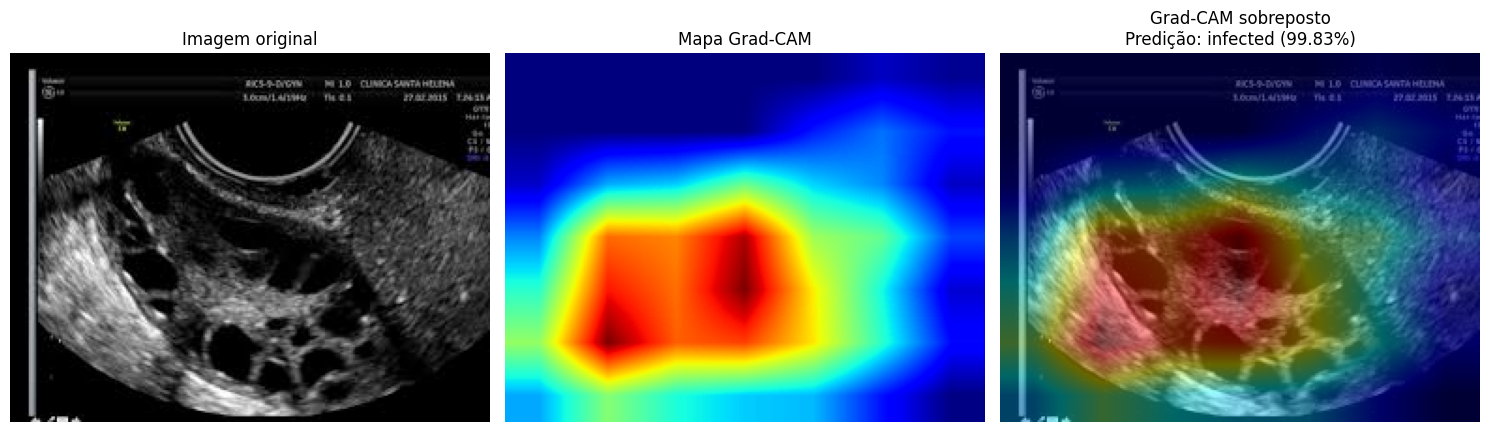

── Grad-CAM ──
Imagem analisada : ovario_br_analises.jpg
Classe prevista  : infected
Confiança        : 99.83%
Interpretação    : regiões mais quentes indicam as áreas que mais influenciaram a decisão do modelo.


In [ ]:
# ============================================================
# Grad-CAM — versão corrigida
# ============================================================

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

model.eval()

# Última camada convolucional da ResNet18
target_layer = model.layer4[-1].conv2

activations = {}

def forward_hook(module, input, output):
    activations["value"] = output
    output.retain_grad()

# Registra hook
hook = target_layer.register_forward_hook(forward_hook)

# Carrega imagem
img_pil = Image.open(IMG_PATH).convert("RGB")
img_tensor = val_transforms(img_pil).unsqueeze(0).to(DEVICE)

# Garante gradiente ativo
img_tensor.requires_grad_(True)

# Forward SEM torch.no_grad()
output = model(img_tensor)

probs = F.softmax(output, dim=1)
class_idx = torch.argmax(probs, dim=1).item()

# Backward na classe prevista
model.zero_grad()
score = output[0, class_idx]
score.backward()

# Recupera ativações e gradientes
activation = activations["value"]
gradient = activation.grad

# Remove hook
hook.remove()

# Calcula Grad-CAM
weights = gradient.mean(dim=(2, 3), keepdim=True)
cam = (weights * activation).sum(dim=1).squeeze()
cam = F.relu(cam)

cam = cam.detach().cpu().numpy()
cam = cam - cam.min()
cam = cam / (cam.max() + 1e-8)

# Nome da classe prevista
idx_to_class = {
    idx: classe
    for classe, idx in train_full_dataset.class_to_idx.items()
}

predicted_class = idx_to_class[class_idx]
confidence = probs[0, class_idx].item() * 100

# Imagem original
img_np = np.array(img_pil)

# Redimensiona Grad-CAM
cam_resized = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))

# Heatmap
heatmap = cv2.applyColorMap(
    np.uint8(255 * cam_resized),
    cv2.COLORMAP_JET
)

heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

# Sobreposição
overlay = np.float32(img_np) * 0.6 + np.float32(heatmap) * 0.4
overlay = np.uint8(overlay)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_np)
axes[0].set_title("Imagem original")
axes[0].axis("off")

axes[1].imshow(cam_resized, cmap="jet")
axes[1].set_title("Mapa Grad-CAM")
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title(f"Grad-CAM sobreposto\nPredição: {predicted_class} ({confidence:.2f}%)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("── Grad-CAM ──")
print(f"Imagem analisada : {IMG_PATH}")
print(f"Classe prevista  : {predicted_class}")
print(f"Confiança        : {confidence:.2f}%")
print("Interpretação    : regiões mais quentes indicam as áreas que mais influenciaram a decisão do modelo.")